# Lab 3.3 — Build a RAG Pipeline from Scratch
### Module 4: Large Language Models | Chitkara University B-Tech AI Specialization
---
**Duration:** 90 minutes | **Mode:** Individual | **Day 3 — Wednesday**

> **Scenario:** You are a Senior AI Engineer at an edtech company called LearnBridge.
> LearnBridge produces detailed PDF study guides for competitive exams (UPSC, JEE, GATE).
> Students ask the chatbot questions like *'What is the difference between RAM and ROM?'*
> or *'Explain the photoelectric effect simply.'*
>
> The problem: if you just send a question straight to GPT-4, it sometimes hallucinates
> — inventing plausible-sounding but incorrect answers. Leadership wants answers to be
> **grounded exclusively in LearnBridge's verified study material.**
>
> Your solution: **Retrieval-Augmented Generation (RAG)** — find the relevant passage
> from the study guide first, then feed it to the LLM as context. The LLM can only
> answer from what you give it. Hallucinations drop dramatically.

**Objective:** Build a complete RAG pipeline — document ingestion, chunking, embedding,
vector store, retrieval, and augmented generation. Compare RAG answers vs naive answers
on 10 factual questions. Measure retrieval quality and answer faithfulness.

---
### This lab runs entirely on Google Colab — no cloud credentials needed
*(Optional: plug in an Azure OpenAI or HuggingFace key for better generation quality)*

**Learning outcomes:**
- Understand every component in the RAG pipeline and why each exists
- Implement document chunking with overlap and explain the trade-offs
- Build an in-memory vector store using cosine similarity
- Write a `retrieve()` function and measure top-K retrieval accuracy
- Construct an augmented prompt with retrieved context
- Quantify hallucination reduction: RAG vs naive generation
- Explain when RAG is the right architecture vs fine-tuning


## Background — The RAG Architecture

RAG was introduced by Lewis et al. (2020) at Facebook AI Research as a way to
give language models access to external knowledge without retraining them.

```
  INDEXING PIPELINE (runs once, offline)
  ─────────────────────────────────────
  Raw Documents
       │
       ▼
  Text Chunking  ──── Split into overlapping passages (e.g., 300 words, 50-word overlap)
       │
       ▼
  Embedding Model ─── Each chunk → dense vector (e.g., 384-dim Sentence-BERT)
       │
       ▼
  Vector Store ──────  Store (chunk_text, embedding_vector) pairs

  QUERY PIPELINE (runs on every user question)
  ──────────────────────────────────────────────
  User Question
       │
       ▼
  Embed Question ──── Same embedding model as indexing
       │
       ▼
  Similarity Search ─ Find top-K most similar chunks (cosine similarity)
       │
       ▼
  Augment Prompt ──── Inject retrieved chunks into the LLM prompt as context
       │
       ▼
  LLM Generation ──── LLM answers ONLY from the provided context
       │
       ▼
  Answer + Source Citations
```

**Why RAG outperforms naive prompting:**
- **Reduces hallucination:** The LLM is grounded in specific retrieved text
- **Stays current:** Update the document store without retraining the LLM
- **Traceable:** Every answer can be traced to a specific source passage
- **Cost-efficient:** No fine-tuning cost. Cheaper than stuffing the whole corpus in-context.

**RAG vs Fine-tuning — when to use which:**
| Scenario | Use RAG | Use Fine-tuning |
|----------|---------|----------------|
| Knowledge changes frequently | ✓ | ✗ |
| Need source citations | ✓ | ✗ |
| Domain-specific *style* or *format* | ✗ | ✓ |
| Very large knowledge base (millions of docs) | ✓ | ✗ |
| Fixed, small, stable knowledge base | Either | ✓ |


## Task 1 — Install packages and create the knowledge base

We create a synthetic LearnBridge study guide covering **Computer Science and Physics**.
In production this would be real PDFs — here we write the content directly as Python strings
so the lab is fully self-contained and reproducible.

**The knowledge base contains 12 passages covering:**
- Memory: RAM, ROM, cache hierarchy
- Operating systems: processes, threads, scheduling
- Networking: TCP/IP, DNS, HTTP/HTTPS
- Physics: Newton's laws, thermodynamics, photoelectric effect
- Data structures: arrays, linked lists, trees, hash tables

This gives us enough material for meaningful retrieval without being so large
that the lab takes too long to run.


In [1]:
!pip install sentence-transformers scikit-learn numpy --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import re, json, time, textwrap
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

print('Packages ready')


Packages ready


In [2]:

# ── LearnBridge synthetic study guide ────────────────────────────────────
# Each entry: (document_id, topic, full_passage_text)
# Passages are ~150-250 words each — realistic textbook paragraph length.

raw_documents = [
    (
        'CS-MEM-01', 'RAM and ROM',
        'Random Access Memory (RAM) is a type of volatile computer memory that stores data '
        'and machine code currently being used by the CPU. It is called volatile because '
        'all data is lost when power is removed. RAM allows data to be read and written '
        'in approximately equal time regardless of the physical location of data inside the '
        'memory chip. Modern computers use DDR4 or DDR5 SDRAM. A typical laptop in 2024 '
        'comes with 8GB to 32GB of RAM. RAM speed is measured in MHz — higher MHz means '
        'faster data transfer between RAM and the CPU. '
        'Read-Only Memory (ROM) is non-volatile memory that retains its contents even when '
        'power is removed. ROM is used to store firmware — permanent software that controls '
        'hardware at the lowest level, such as the BIOS or UEFI that initialises the '
        'computer when you press the power button. Unlike RAM, ROM cannot be modified '
        'during normal operation, though modern variants like EEPROM and Flash memory '
        'allow controlled rewriting. The key difference: RAM is fast, large, and temporary; '
        'ROM is slower, smaller, and permanent.'
    ),
    (
        'CS-MEM-02', 'Cache Memory',
        'Cache memory is a small, extremely fast memory layer situated between the CPU '
        'and main RAM. Its purpose is to store frequently accessed data and instructions '
        'so the CPU does not have to wait for the slower main memory on every access. '
        'Cache operates on the principle of locality: temporal locality means recently '
        'used data will likely be needed again soon; spatial locality means data near '
        'recently used data will likely be needed next. '
        'Modern CPUs have three cache levels: L1 cache is the fastest (4-64 KB, '
        'less than 1 nanosecond access time) and sits directly inside the CPU core. '
        'L2 cache is larger (256 KB to 4 MB, ~5 ns) and is either per-core or shared. '
        'L3 cache is the largest (8-64 MB, ~20 ns) and is shared across all CPU cores. '
        'A cache miss — when requested data is not in cache — forces the CPU to fetch '
        'from RAM, causing a stall of 100-300 nanoseconds. Efficient programs are designed '
        'to maximise cache hits by accessing memory in predictable sequential patterns.'
    ),
    (
        'CS-OS-01', 'Processes and Threads',
        'A process is an instance of a program in execution. When you open a web browser, '
        'the operating system creates a process with its own private memory space, file '
        'handles, and CPU registers. Processes are isolated from each other by the OS '
        'for security and stability — one crashing process cannot corrupt another. '
        'Inter-process communication (IPC) uses mechanisms like pipes, sockets, and '
        'shared memory to allow processes to exchange data. '
        'A thread is the smallest unit of execution within a process. Multiple threads '
        'share the same memory space of their parent process, making thread creation '
        'much cheaper than process creation. Threads within one process can communicate '
        'directly through shared memory but must synchronise access using locks, mutexes, '
        'or semaphores to avoid race conditions. '
        'Modern applications are multithreaded: a web server handles each request in a '
        'separate thread. The CPU rapidly switches between threads using context switching, '
        'creating the illusion of parallel execution even on a single core.'
    ),
    (
        'CS-OS-02', 'CPU Scheduling',
        'CPU scheduling is the OS mechanism that decides which process or thread gets '
        'CPU time and for how long. Since most systems have more processes than CPU cores, '
        'the scheduler multiplexes the CPU among competing processes. '
        'First-Come-First-Served (FCFS) is the simplest scheduler: processes are executed '
        'in arrival order. It is fair but suffers from the convoy effect where short jobs '
        'wait behind long ones. '
        'Shortest Job First (SJF) minimises average waiting time by always running the '
        'shortest available job next. However, it can starve long jobs if short jobs '
        'keep arriving. '
        'Round Robin gives each process a fixed time quantum (e.g., 10 ms) in rotation. '
        'It is the basis of modern OS schedulers and ensures no process waits too long. '
        'Priority scheduling assigns a priority number to each process; higher priority '
        'processes run first. Most real OSes use a combination: multilevel feedback queues '
        'that dynamically adjust priority based on CPU and I/O behaviour.'
    ),
    (
        'CS-NET-01', 'TCP/IP Model',
        'The TCP/IP model is the foundational framework for internet communication, '
        'consisting of four layers. The Application Layer (top) contains protocols '
        'like HTTP, HTTPS, FTP, SMTP, and DNS that applications use directly. '
        'The Transport Layer contains TCP (Transmission Control Protocol) and '
        'UDP (User Datagram Protocol). TCP provides reliable, ordered delivery with '
        'error checking and retransmission; it is used for web pages and email where '
        'data integrity matters. UDP sacrifices reliability for speed and is used '
        'for video streaming and online gaming where a dropped packet is preferable '
        'to waiting for retransmission. '
        'The Internet Layer routes packets across networks using IP addresses. '
        'IPv4 uses 32-bit addresses (e.g., 192.168.1.1); IPv6 uses 128-bit addresses '
        'to solve address exhaustion. '
        'The Network Access Layer handles physical transmission over Ethernet, WiFi, or fibre.'
    ),
    (
        'CS-NET-02', 'DNS and HTTP',
        'The Domain Name System (DNS) translates human-readable domain names like '
        'www.google.com into IP addresses like 142.250.195.46. When you type a URL '
        'in your browser, the OS first checks its local DNS cache, then queries a '
        'recursive resolver (usually provided by your ISP or Google 8.8.8.8), which '
        'walks the DNS hierarchy from root servers to authoritative name servers. '
        'DNS uses UDP on port 53 for speed, switching to TCP only for large responses. '
        'HTTP (HyperText Transfer Protocol) is a request-response protocol for '
        'transferring web content. A client sends a request (GET, POST, PUT, DELETE) '
        'and the server responds with a status code and body. Common status codes: '
        '200 OK, 301 Redirect, 404 Not Found, 500 Internal Server Error. '
        'HTTPS adds TLS/SSL encryption to HTTP, preventing eavesdropping and ensuring '
        'the server is who it claims to be via digital certificates. All modern websites '
        'should use HTTPS — browsers now flag plain HTTP sites as insecure.'
    ),
    (
        'CS-DS-01', 'Arrays and Linked Lists',
        'An array is a contiguous block of memory storing elements of the same type. '
        'Elements are accessed in O(1) time using an index because the memory address '
        'of any element can be calculated directly: base_address + (index × element_size). '
        'Arrays are cache-friendly because sequential access exploits spatial locality. '
        'The main limitation is fixed size and expensive insertion/deletion: inserting '
        'at position i requires shifting all elements from i to n, costing O(n) time. '
        'A linked list stores elements as nodes, where each node contains data and a '
        'pointer to the next node. Insertion and deletion at any position costs O(1) '
        'if you already have a pointer to that node, because you only update pointers. '
        'However, accessing the k-th element requires traversing from the head, costing O(k). '
        'Linked lists are not cache-friendly because nodes can be scattered anywhere in memory. '
        'Use arrays when you need fast random access; use linked lists when you need '
        'frequent insertions and deletions at arbitrary positions.'
    ),
    (
        'CS-DS-02', 'Hash Tables',
        'A hash table stores key-value pairs and supports O(1) average-case insertion, '
        'deletion, and lookup. It works by applying a hash function to the key to compute '
        'an array index, then storing the value at that index. A good hash function '
        'distributes keys uniformly across the array to minimise collisions. '
        'A collision occurs when two different keys hash to the same index. '
        'Chaining resolves collisions by storing a linked list at each array slot — '
        'multiple keys that hash to the same slot form a chain. '
        'Open addressing resolves collisions by probing for the next empty slot '
        'using linear probing, quadratic probing, or double hashing. '
        'The load factor (number of elements / array size) determines performance: '
        'a load factor above 0.7 typically triggers a resize (rehashing all elements '
        'into a larger array). Python dictionaries and Java HashMaps are hash tables. '
        'Worst-case performance is O(n) when all keys collide, but this is rare with '
        'a good hash function.'
    ),
    (
        'PHY-MECH-01', "Newton's Laws of Motion",
        "Newton's First Law (Law of Inertia) states that an object at rest stays at rest "
        'and an object in motion continues with the same velocity unless acted upon by '
        'a net external force. This explains why a passenger lurches forward when a bus '
        'brakes suddenly — the passenger\'s body tends to continue at the previous velocity. '
        "Newton's Second Law states that the net force on an object equals its mass times "
        'acceleration: F = ma. This is the most used equation in classical mechanics. '
        'If a 2 kg object has a net force of 10 N applied, its acceleration is 5 m/s². '
        "Newton's Third Law states that for every action there is an equal and opposite "
        'reaction. When a rocket expels gas backward at high speed (action), the rocket '
        'is propelled forward (reaction). When you push against a wall, the wall pushes '
        'back on you with equal force. These three laws form the foundation of classical '
        'mechanics and remain valid for all everyday speeds (much less than the speed of light).'
    ),
    (
        'PHY-THERM-01', 'Laws of Thermodynamics',
        'The Zeroth Law establishes thermal equilibrium: if system A is in thermal equilibrium '
        'with system B, and B with C, then A is in equilibrium with C. This is the basis '
        'for temperature measurement. '
        'The First Law is conservation of energy: the total energy of an isolated system '
        'is constant. Energy can be converted between heat and work but cannot be created '
        'or destroyed. ΔU = Q - W, where ΔU is the change in internal energy, Q is heat '
        'added to the system, and W is work done by the system. '
        'The Second Law introduces entropy: in any irreversible process, the total entropy '
        'of the universe increases. Heat always flows from hot to cold spontaneously, never '
        'in reverse without work input. This is why refrigerators require electricity. '
        'The Third Law states that the entropy of a perfect crystal approaches zero as '
        'temperature approaches absolute zero (0 Kelvin = −273.15°C). '
        'Absolute zero is unattainable in practice — we can get arbitrarily close but never reach it.'
    ),
    (
        'PHY-QUANT-01', 'Photoelectric Effect',
        'The photoelectric effect is the emission of electrons from a metal surface when '
        'light of sufficient frequency shines on it. It was explained by Albert Einstein '
        'in 1905, for which he received the Nobel Prize in Physics in 1921. '
        'Classical wave theory predicted that any frequency of light, if intense enough, '
        'should eject electrons — but experiments showed this was wrong. '
        'Einstein proposed that light consists of discrete energy packets called photons, '
        'each with energy E = hf, where h is Planck\'s constant (6.626 × 10⁻³⁴ J·s) '
        'and f is the frequency of light. '
        'An electron is ejected only if a single photon carries enough energy to overcome '
        'the work function (φ) of the metal — the minimum energy needed to release an electron. '
        'The kinetic energy of the ejected electron is KE = hf − φ. '
        'If hf < φ, no electrons are emitted regardless of light intensity. '
        'This discovery proved that light has particle-like properties and was a cornerstone '
        'of quantum mechanics.'
    ),
    (
        'CS-DS-03', 'Binary Trees and BSTs',
        'A binary tree is a hierarchical data structure where each node has at most two '
        'children, referred to as the left child and right child. The topmost node is the root. '
        'Tree height is the number of edges on the longest path from root to leaf. '
        'A Binary Search Tree (BST) adds an ordering property: for every node, all values '
        'in the left subtree are smaller, and all values in the right subtree are larger. '
        'This property enables O(log n) search, insertion, and deletion on average — '
        'you can eliminate half the remaining nodes at each step, similar to binary search. '
        'Tree traversals visit nodes in different orders: in-order (left, root, right) '
        'visits a BST in sorted ascending order; pre-order (root, left, right) is used '
        'to copy a tree; post-order (left, right, root) is used to delete a tree. '
        'Worst case for a BST is O(n) if the tree degenerates into a linked list (all nodes '
        'inserted in sorted order). Self-balancing trees like AVL trees and Red-Black trees '
        'maintain O(log n) worst case by automatically rebalancing after insertions.'
    ),
]

print(f'Knowledge base loaded: {len(raw_documents)} documents')
print()
for doc_id, topic, text in raw_documents:
    word_count = len(text.split())
    print(f'  [{doc_id}]  {topic:<35}  {word_count} words')


Knowledge base loaded: 12 documents

  [CS-MEM-01]  RAM and ROM                          178 words
  [CS-MEM-02]  Cache Memory                         173 words
  [CS-OS-01]  Processes and Threads                157 words
  [CS-OS-02]  CPU Scheduling                       153 words
  [CS-NET-01]  TCP/IP Model                         126 words
  [CS-NET-02]  DNS and HTTP                         153 words
  [CS-DS-01]  Arrays and Linked Lists              159 words
  [CS-DS-02]  Hash Tables                          156 words
  [PHY-MECH-01]  Newton's Laws of Motion              171 words
  [PHY-THERM-01]  Laws of Thermodynamics               166 words
  [PHY-QUANT-01]  Photoelectric Effect                 164 words
  [CS-DS-03]  Binary Trees and BSTs                178 words


## Task 2 — Document chunking

Even though our passages are already reasonably short, real production documents
(PDFs, textbooks, web pages) are much longer. Chunking splits them into pieces
that fit within an embedding model's input limit and are specific enough for
precise retrieval.

### Why chunking matters
- Embedding models have a token limit (e.g., 512 tokens for BERT-based models)
- A 50-page document embedded as one vector loses all fine-grained detail —
  every question gets the same document back
- Smaller chunks = more precise retrieval but more chunks to search
- **The chunking sweet spot:** 100-400 words with 10-20% overlap

### Why overlap?
If a sentence is split exactly at a chunk boundary, important context may be
split across two chunks — neither containing the complete thought.
Overlap (repeating the last N words in the next chunk) prevents this.

```
Chunk 1: [word_1 ... word_200]
Chunk 2: [word_151 ... word_350]   ← 50-word overlap with chunk 1
Chunk 3: [word_301 ... word_500]   ← 50-word overlap with chunk 2
```


In [3]:
def chunk_text(text, chunk_size=120, overlap=25):
    '''
    Split text into overlapping word-based chunks.

    Parameters
    ----------
    text       : the full document text as a single string
    chunk_size : number of words per chunk (default 120)
    overlap    : number of words repeated between consecutive chunks (default 25)

    Returns
    -------
    List of (chunk_text, start_word_idx, end_word_idx) tuples.
    '''
    words = text.split()
    chunks = []
    start = 0
    while start < len(words):
        end = min(start + chunk_size, len(words))
        chunk_words = words[start:end]
        chunks.append((' '.join(chunk_words), start, end))
        if end == len(words):
            break
        start += chunk_size - overlap  # move forward by (chunk_size - overlap)
    return chunks


# ── Index all 12 documents ────────────────────────────────────────────────
# Each entry in the vector store: (chunk_text, metadata_dict)
vector_store_texts = []  # list of chunk strings
vector_store_meta  = []  # list of metadata dicts for each chunk

CHUNK_SIZE = 120   # words per chunk
OVERLAP    = 25    # words of overlap between consecutive chunks

for doc_id, topic, text in raw_documents:
    chunks = chunk_text(text, chunk_size=CHUNK_SIZE, overlap=OVERLAP)
    for i, (chunk, start, end) in enumerate(chunks):
        vector_store_texts.append(chunk)
        vector_store_meta.append({
            'doc_id'     : doc_id,
            'topic'      : topic,
            'chunk_idx'  : i,
            'word_start' : start,
            'word_end'   : end,
            'word_count' : len(chunk.split()),
        })

print(f'Chunking complete')
print(f'  Documents         : {len(raw_documents)}')
print(f'  Chunk size        : {CHUNK_SIZE} words')
print(f'  Overlap           : {OVERLAP} words  ({OVERLAP/CHUNK_SIZE:.0%} of chunk size)')
print(f'  Total chunks      : {len(vector_store_texts)}')
print(f'  Avg chunks/doc    : {len(vector_store_texts)/len(raw_documents):.1f}')
print()

# Show chunks for the first document to make the structure concrete
first_doc_chunks = [
    (i, meta, text)
    for i, (meta, text) in enumerate(zip(vector_store_meta, vector_store_texts))
    if meta['doc_id'] == raw_documents[0][0]
]
print(f'Chunks for document "{raw_documents[0][1]}" (doc_id={raw_documents[0][0]}):')
for idx, meta, chunk_text_val in first_doc_chunks:
    print(f'\n  Chunk {meta["chunk_idx"]}  (words {meta["word_start"]}-{meta["word_end"]})')
    # Show the first and last 15 words of the chunk
    words = chunk_text_val.split()
    preview = ' '.join(words[:15]) + ' ... ' + ' '.join(words[-10:])
    print(f'  {preview}')
print()
print('Notice: the last words of chunk 0 reappear at the start of chunk 1 (overlap).')


Chunking complete
  Documents         : 12
  Chunk size        : 120 words
  Overlap           : 25 words  (21% of chunk size)
  Total chunks      : 24
  Avg chunks/doc    : 2.0

Chunks for document "RAM and ROM" (doc_id=CS-MEM-01):

  Chunk 0  (words 0-120)
  Random Access Memory (RAM) is a type of volatile computer memory that stores data and ... removed. ROM is used to store firmware — permanent software

  Chunk 1  (words 95-178)
  CPU. Read-Only Memory (ROM) is non-volatile memory that retains its contents even when power is ... fast, large, and temporary; ROM is slower, smaller, and permanent.

Notice: the last words of chunk 0 reappear at the start of chunk 1 (overlap).


## Task 3 — Embed all chunks and build the vector store

We use **Sentence-BERT all-MiniLM-L6-v2** — the same model from Lab 1.3.
Each chunk becomes a 384-dimensional dense vector.

**Why the same embedding model for both indexing and querying matters:**
The embedding model defines the geometry of the vector space. If you embed documents
with Model A and queries with Model B, their vectors live in different spaces and
cosine similarity between them is meaningless.
Always use **the same model** for both document embedding (offline) and query embedding (online).

**Download:** all-MiniLM-L6-v2 is ~80 MB. Cached after first Colab run.


In [4]:
from sentence_transformers import SentenceTransformer

print('Loading Sentence-BERT all-MiniLM-L6-v2...')
print('(~80 MB download on first run, then cached)')

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f'Model loaded — embedding dimension: {embed_model.get_sentence_embedding_dimension()}')
print()

# ── Embed all chunks ──────────────────────────────────────────────────────
print(f'Embedding {len(vector_store_texts)} chunks...')
t_start = time.time()

# encode() returns a numpy array of shape (n_chunks, 384)
# normalize_embeddings=True makes cosine similarity == dot product (faster at query time)
chunk_embeddings = embed_model.encode(
    vector_store_texts,
    normalize_embeddings=True,
    batch_size=32,
    show_progress_bar=True,
)

t_index = time.time() - t_start

print(f'\nIndexing complete!')
print(f'  Embedding matrix shape : {chunk_embeddings.shape}')
print(f'  Memory footprint       : {chunk_embeddings.nbytes / 1024:.1f} KB')
print(f'  Indexing time          : {t_index:.2f}s')
print(f'  Throughput             : {len(vector_store_texts)/t_index:.0f} chunks/second')
print()
print('The vector store is now ready.')
print('Each row in chunk_embeddings corresponds to the same-index entry in')
print('vector_store_texts (the chunk text) and vector_store_meta (its metadata).')


Loading Sentence-BERT all-MiniLM-L6-v2...
(~80 MB download on first run, then cached)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded — embedding dimension: 384

Embedding 24 chunks...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Indexing complete!
  Embedding matrix shape : (24, 384)
  Memory footprint       : 36.0 KB
  Indexing time          : 0.83s
  Throughput             : 29 chunks/second

The vector store is now ready.
Each row in chunk_embeddings corresponds to the same-index entry in
vector_store_texts (the chunk text) and vector_store_meta (its metadata).


## Task 4 — Build the retrieval function and test it

The retrieval function is the heart of RAG. It:
1. Embeds the user's query with the **same** Sentence-BERT model
2. Computes cosine similarity between the query vector and all chunk vectors
3. Returns the top-K chunks with the highest similarity scores

### What does top-K look like in practice?
- **K=1:** Retrieve only the single most relevant chunk. Fast but risky — if retrieval
  misses, the LLM has nothing useful.
- **K=3:** Standard default. Gives the LLM 3 relevant passages to work from.
- **K=5:** Safer for complex multi-part questions but uses more of the LLM's context window.

### Retrieval quality metric: Recall@K
For a question where we know which document contains the answer:
- **Recall@1:** Did the correct document appear in the top-1 result? (strictest)
- **Recall@3:** Did the correct document appear in the top-3 results?
- **Recall@5:** Did the correct document appear in the top-5 results?

A good RAG system should have Recall@3 ≥ 0.85 on well-formed questions.


In [5]:
def retrieve(query, k=3, embed_model=embed_model,
             chunk_embs=chunk_embeddings,
             texts=vector_store_texts,
             meta=vector_store_meta):
    '''
    Find the top-K most relevant chunks for a query.

    Parameters
    ----------
    query      : user question as a string
    k          : number of chunks to return

    Returns
    -------
    List of dicts, sorted by similarity (highest first):
      {'rank', 'score', 'text', 'doc_id', 'topic', 'chunk_idx'}
    '''
    # Step 1: Embed the query (single vector, 384-dim)
    query_vec = embed_model.encode([query], normalize_embeddings=True)  # shape (1, 384)

    # Step 2: Cosine similarity against all chunk embeddings
    # cos_sim shape: (1, n_chunks) — one score per chunk
    scores = cosine_similarity(query_vec, chunk_embs)[0]  # shape (n_chunks,)

    # Step 3: Get indices of top-K highest scores
    top_k_indices = scores.argsort()[::-1][:k]

    # Step 4: Build result list
    results = []
    for rank, idx in enumerate(top_k_indices, 1):
        results.append({
            'rank'      : rank,
            'score'     : round(float(scores[idx]), 4),
            'text'      : texts[idx],
            'doc_id'    : meta[idx]['doc_id'],
            'topic'     : meta[idx]['topic'],
            'chunk_idx' : meta[idx]['chunk_idx'],
        })
    return results


# ── Demo: test with 5 questions ───────────────────────────────────────────
demo_questions = [
    'What is the difference between RAM and ROM?',
    'How does the photoelectric effect work?',
    'What is the difference between a process and a thread?',
    'How does a hash table handle collisions?',
    'What is Newton second law of motion?',
]

print('RETRIEVAL DEMO — Top-3 chunks per question')
print('=' * 72)

for question in demo_questions:
    results = retrieve(question, k=3)
    print(f'\nQ: "{question}"')
    for r in results:
        print(f'  [{r["rank"]}] score={r["score"]:.4f}  '
              f'[{r["doc_id"]}]  "{r["topic"]}"  (chunk {r["chunk_idx"]})')
        # Show the first 100 chars of the retrieved chunk
        print(f'       {r["text"][:100]}...')


RETRIEVAL DEMO — Top-3 chunks per question

Q: "What is the difference between RAM and ROM?"
  [1] score=0.7432  [CS-MEM-01]  "RAM and ROM"  (chunk 1)
       CPU. Read-Only Memory (ROM) is non-volatile memory that retains its contents even when power is remo...
  [2] score=0.6814  [CS-MEM-01]  "RAM and ROM"  (chunk 0)
       Random Access Memory (RAM) is a type of volatile computer memory that stores data and machine code c...
  [3] score=0.4158  [CS-MEM-02]  "Cache Memory"  (chunk 0)
       Cache memory is a small, extremely fast memory layer situated between the CPU and main RAM. Its purp...

Q: "How does the photoelectric effect work?"
  [1] score=0.6539  [PHY-QUANT-01]  "Photoelectric Effect"  (chunk 0)
       The photoelectric effect is the emission of electrons from a metal surface when light of sufficient ...
  [2] score=0.4405  [PHY-QUANT-01]  "Photoelectric Effect"  (chunk 1)
       electron is ejected only if a single photon carries enough energy to overcome the work function

In [6]:
# ── Measure Recall@K on 10 labelled questions ────────────────────────────
# Each entry: (question, expected_doc_id)
# expected_doc_id is the document we KNOW contains the correct answer.
labelled_questions = [
    ('What is the difference between RAM and ROM?',               'CS-MEM-01'),
    ('What is cache memory and why does it exist?',               'CS-MEM-02'),
    ('How does a CPU scheduler work?',                            'CS-OS-02'),
    ('What is the difference between a process and a thread?',    'CS-OS-01'),
    ('How does DNS translate domain names?',                      'CS-NET-02'),
    ('What is the difference between TCP and UDP?',               'CS-NET-01'),
    ('When should I use an array vs a linked list?',              'CS-DS-01'),
    ('How does a hash table handle collisions?',                  'CS-DS-02'),
    ('How does the photoelectric effect work?',                   'PHY-QUANT-01'),
    ('State and explain Newton laws of motion',                   'PHY-MECH-01'),
]

print('RECALL@K EVALUATION — 10 labelled questions')
print('='*60)

recall_at = {1: 0, 3: 0, 5: 0}
details   = []

for question, expected_doc in labelled_questions:
    top5 = retrieve(question, k=5)
    retrieved_docs = [r['doc_id'] for r in top5]

    r_at_1 = expected_doc == retrieved_docs[0]
    r_at_3 = expected_doc in retrieved_docs[:3]
    r_at_5 = expected_doc in retrieved_docs[:5]

    if r_at_1: recall_at[1] += 1
    if r_at_3: recall_at[3] += 1
    if r_at_5: recall_at[5] += 1

    details.append({
        'Question'    : question[:60],
        'Expected'    : expected_doc,
        'Top-1 Doc'   : retrieved_docs[0],
        'Top-1 Score' : top5[0]['score'],
        'R@1'         : 'HIT' if r_at_1 else 'miss',
        'R@3'         : 'HIT' if r_at_3 else 'miss',
    })

n = len(labelled_questions)
print(f'  Recall@1 : {recall_at[1]}/{n} = {recall_at[1]/n:.0%}')
print(f'  Recall@3 : {recall_at[3]}/{n} = {recall_at[3]/n:.0%}')
print(f'  Recall@5 : {recall_at[5]}/{n} = {recall_at[5]/n:.0%}')
print()
df_recall = pd.DataFrame(details)
print(df_recall[['Question','Expected','Top-1 Doc','Top-1 Score','R@1','R@3']].to_string(index=False))


RECALL@K EVALUATION — 10 labelled questions
  Recall@1 : 10/10 = 100%
  Recall@3 : 10/10 = 100%
  Recall@5 : 10/10 = 100%

                                              Question     Expected    Top-1 Doc  Top-1 Score R@1 R@3
           What is the difference between RAM and ROM?    CS-MEM-01    CS-MEM-01       0.7432 HIT HIT
           What is cache memory and why does it exist?    CS-MEM-02    CS-MEM-02       0.7483 HIT HIT
                        How does a CPU scheduler work?     CS-OS-02     CS-OS-02       0.6292 HIT HIT
What is the difference between a process and a thread?     CS-OS-01     CS-OS-01       0.7576 HIT HIT
                  How does DNS translate domain names?    CS-NET-02    CS-NET-02       0.6381 HIT HIT
           What is the difference between TCP and UDP?    CS-NET-01    CS-NET-01       0.6037 HIT HIT
          When should I use an array vs a linked list?     CS-DS-01     CS-DS-01       0.6664 HIT HIT
              How does a hash table handle collisions?     CS

## Task 5 — Augmented generation

Now we combine retrieval with generation. The **augmented prompt** template is:

```
You are a study assistant for LearnBridge educational platform.
Answer the student's question using ONLY the information in the provided context.
If the context does not contain the answer, say: 'This topic is not covered in
the current study material.'
Do NOT use any knowledge outside of the provided context passages.

CONTEXT:
[Passage 1 — Source: CS-MEM-01, RAM and ROM, Chunk 0]
Random Access Memory (RAM) is a type of volatile computer memory...

[Passage 2 — Source: CS-MEM-01, RAM and ROM, Chunk 1]
...

STUDENT QUESTION: What is the difference between RAM and ROM?

ANSWER:
```

### Key design decisions in this prompt:
1. **'ONLY the information in the provided context'** — grounds the model, prevents hallucination
2. **Explicit fallback phrase** — if retrieval fails, the model admits it rather than hallucinating
3. **Source labels** in context — allows generating citations in the answer
4. **Temperature = 0.1** — legal/factual writing needs consistency; this is study material

We use **local GPT-2** as the generator by default (free, zero credentials).
Plug in an Azure or HuggingFace key for dramatically better answers.


In [7]:
# ── LLM generation backend — same unified wrapper from Labs 2.1 and 3.1 ──
USE_AZURE = False
AZURE_ENDPOINT   = 'https://YOUR-RESOURCE.openai.azure.com/'
AZURE_KEY        = 'YOUR_KEY_HERE'
AZURE_DEPLOYMENT = 'gpt-35-turbo'
AZURE_API_VERSION= '2024-02-01'

USE_HF    = False
HF_TOKEN  = 'hf_YOUR_TOKEN_HERE'
HF_MODEL  = 'mistralai/Mistral-7B-Instruct-v0.3'

USE_LOCAL = True   # GPT-2 fallback — works with zero setup

_local_gen = None

def llm_generate(system_prompt, user_prompt, temperature=0.1, max_tokens=300):
    # Call the configured LLM and return the response string.
    if USE_AZURE:
        from openai import AzureOpenAI
        client = AzureOpenAI(azure_endpoint=AZURE_ENDPOINT,
                             api_key=AZURE_KEY, api_version=AZURE_API_VERSION)
        resp = client.chat.completions.create(
            model=AZURE_DEPLOYMENT,
            messages=[{'role':'system','content':system_prompt},
                      {'role':'user',  'content':user_prompt}],
            temperature=temperature, max_tokens=max_tokens)
        return resp.choices[0].message.content.strip()

    elif USE_HF:
        import requests as req
        prompt = f'[INST] {system_prompt}\n{user_prompt} [/INST]'
        r = req.post(f'https://api-inference.huggingface.co/models/{HF_MODEL}',
                     headers={'Authorization': f'Bearer {HF_TOKEN}'},
                     json={'inputs': prompt,
                           'parameters': {'max_new_tokens': max_tokens,
                                          'temperature': max(temperature, 0.01),
                                          'return_full_text': False}},
                     timeout=60)
        data = r.json()
        return data[0]['generated_text'].strip() if isinstance(data, list) else str(data)

    else:  # LOCAL GPT-2
        global _local_gen
        if _local_gen is None:
            from transformers import pipeline as hp
            print('Loading GPT-2 generator...')
            _local_gen = hp('text-generation', model='gpt2', device=-1)
        # GPT-2 has no system/user concept — concatenate into one prompt
        full_prompt = f'{system_prompt}\n\n{user_prompt}\nAnswer:'
        # Truncate to fit GPT-2 context (1024 tokens)
        prompt_words = full_prompt.split()
        if len(prompt_words) > 700:
            full_prompt = ' '.join(prompt_words[:700])
        out = _local_gen(full_prompt, max_new_tokens=min(max_tokens, 100),
                         temperature=max(temperature, 0.1), do_sample=True,
                         pad_token_id=50256)
        return out[0]['generated_text'][len(full_prompt):].strip()

print('LLM generator configured.')
active = 'Azure' if USE_AZURE else ('HuggingFace' if USE_HF else 'Local GPT-2')
print(f'Active backend: {active}')
if active == 'Local GPT-2':
    print('TIP: GPT-2 answer quality is limited. Set USE_AZURE or USE_HF to True for much better answers.')


LLM generator configured.
Active backend: Local GPT-2
TIP: GPT-2 answer quality is limited. Set USE_AZURE or USE_HF to True for much better answers.


In [8]:
# ── The core RAG function ─────────────────────────────────────────────────
def rag_answer(question, k=3, temperature=0.1, max_tokens=300, verbose=False):
    '''
    Full RAG pipeline: retrieve relevant chunks then generate a grounded answer.

    Parameters
    ----------
    question    : student question string
    k           : number of chunks to retrieve
    temperature : LLM temperature (low = consistent, factual)
    verbose     : if True, print retrieved chunks before the answer

    Returns
    -------
    dict with keys: answer, retrieved_chunks, latency_s
    '''
    t0 = time.time()

    # Step 1 — Retrieve top-K relevant chunks
    chunks = retrieve(question, k=k)

    # Step 2 — Build context block with source labels
    context_block = ''
    for i, chunk in enumerate(chunks, 1):
        context_block += (
            f'[Passage {i} — Source: {chunk["doc_id"]}, {chunk["topic"]}, '
            f'Chunk {chunk["chunk_idx"]} | Relevance score: {chunk["score"]:.3f}]\n'
            f'{chunk["text"]}\n\n'
        )

    # Step 3 — Build augmented prompt
    system_prompt = (
        'You are a study assistant for LearnBridge educational platform.\n'
        'Answer the student question using ONLY the information in the provided context passages.\n'
        'If the context does not contain the answer, respond with exactly:\n'
        '  "This topic is not covered in the current study material."\n'
        'Be accurate, clear, and helpful. Cite the source passage number when possible.'
    )
    user_prompt = (
        f'CONTEXT:\n{context_block}\n'
        f'STUDENT QUESTION: {question}\n\n'
        f'ANSWER:'
    )

    if verbose:
        print('--- RETRIEVED CONTEXT ---')
        for chunk in chunks:
            print(f'  [{chunk["rank"]}] {chunk["doc_id"]} | {chunk["topic"]} | score={chunk["score"]:.4f}')
            print(f'      {chunk["text"][:120]}...')
        print()

    # Step 4 — Generate answer from context
    answer = llm_generate(system_prompt, user_prompt,
                          temperature=temperature, max_tokens=max_tokens)

    return {
        'answer'           : answer,
        'retrieved_chunks' : chunks,
        'latency_s'        : round(time.time() - t0, 3),
    }


# ── Full pipeline demo ────────────────────────────────────────────────────
print('RAG PIPELINE — Full demo with verbose output')
print('=' * 70)

test_q = 'What is the difference between RAM and ROM?'
result = rag_answer(test_q, k=3, verbose=True)

print(f'QUESTION: {test_q}')
print(f'ANSWER:')
print(f'  {result["answer"]}')
print(f'\nTotal latency: {result["latency_s"]}s')


RAG PIPELINE — Full demo with verbose output
--- RETRIEVED CONTEXT ---
  [1] CS-MEM-01 | RAM and ROM | score=0.7432
      CPU. Read-Only Memory (ROM) is non-volatile memory that retains its contents even when power is removed. ROM is used to ...
  [2] CS-MEM-01 | RAM and ROM | score=0.6814
      Random Access Memory (RAM) is a type of volatile computer memory that stores data and machine code currently being used ...
  [3] CS-MEM-02 | Cache Memory | score=0.4158
      Cache memory is a small, extremely fast memory layer situated between the CPU and main RAM. Its purpose is to store freq...

Loading GPT-2 generator...


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


QUESTION: What is the difference between RAM and ROM?
ANSWER:
  RAM is a type of volatile computer memory that stores data and machine code currently being used by the CPU. RAM allows data to be read and written in approximately equal time regardless of the physical location of data inside the memory chip. Modern computers use DDR4 or DDR5 SDRAM. A typical laptop in 2024 comes with 8GB to 32GB of RAM. RAM speed is measured in MHz — higher MHz means faster data transfer between RAM and the CPU. Read-Only Memory (ROM)

Total latency: 26.759s


## Task 6 — RAG vs Naive: head-to-head comparison

The most important experiment: compare RAG answers to **naive generation**
(sending the question directly to the LLM with no retrieved context).

We run 10 questions through both pipelines and evaluate each answer on:

| Dimension | What it measures | Score 1-5 |
|-----------|-----------------|----------|
| **Factual Accuracy** | Are the stated facts correct? | 1=mostly wrong, 5=fully correct |
| **Groundedness** | Does the answer stick to the provided source? | 1=invented facts, 5=only from context |
| **Completeness** | Does it fully answer what was asked? | 1=misses key points, 5=complete |

After running both pipelines, read each pair and fill in your scores below.
Be ruthless — this is about catching hallucinations, not rewarding fluency.


In [9]:
def naive_answer(question, max_tokens=250):
    # Ask the LLM directly with NO retrieved context — pure parametric knowledge.
    system_prompt = (
        'You are a study assistant helping students understand Computer Science '
        'and Physics concepts. Answer the question clearly and accurately.'
    )
    return llm_generate(system_prompt, f'Question: {question}\nAnswer:',
                        temperature=0.1, max_tokens=max_tokens)


# ── 10 evaluation questions ───────────────────────────────────────────────
eval_questions = [
    'What is the difference between RAM and ROM?',
    'Explain how cache memory improves CPU performance.',
    'What is the difference between a process and a thread in an operating system?',
    'How does Round Robin CPU scheduling work?',
    'What is the difference between TCP and UDP?',
    'How does DNS work when you type a URL in your browser?',
    'When should you use an array instead of a linked list?',
    'How does a hash table handle two keys that produce the same hash?',
    'Explain the photoelectric effect and why it disproved classical wave theory.',
    'State Newton three laws of motion with a real-world example for each.',
]

print('Running RAG and Naive pipelines on 10 questions...')
print('This may take 1-3 minutes depending on your backend.')
print()

rag_answers   = []
naive_answers = []

for i, q in enumerate(eval_questions, 1):
    print(f'  [{i:2d}/10] {q[:65]}')
    rag_res   = rag_answer(q, k=3)
    naive_res = naive_answer(q)
    rag_answers.append(rag_res['answer'])
    naive_answers.append(naive_res)

print('\nAll 10 questions answered. Displaying results...')


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Running RAG and Naive pipelines on 10 questions...
This may take 1-3 minutes depending on your backend.

  [ 1/10] What is the difference between RAM and ROM?


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [ 2/10] Explain how cache memory improves CPU performance.


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

  [ 9/10] Explain the photoelectric effect and why it disproved classical w


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  [10/10] State Newton three laws of motion with a real-world example for e


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



All 10 questions answered. Displaying results...


In [10]:
# ── Display all 10 comparison pairs ──────────────────────────────────────
from IPython.display import HTML, display

html_parts = ['<h3 style="font-family:sans-serif;margin-top:20px">'
              'RAG vs Naive — 10 Question Comparison</h3>']

for i, (q, rag_a, naive_a) in enumerate(zip(eval_questions, rag_answers, naive_answers), 1):
    safe_q     = q.replace('<','&lt;').replace('>','&gt;')
    safe_rag   = rag_a.replace('<','&lt;').replace('>','&gt;')[:600]
    safe_naive = naive_a.replace('<','&lt;').replace('>','&gt;')[:600]
    if len(rag_a) > 600:   safe_rag   += ' [...]'
    if len(naive_a) > 600: safe_naive += ' [...]'

    html_parts.append(
        f'<div style="border:1px solid #E5E7EB;border-radius:8px;margin:14px 0;'
        f'overflow:hidden;font-family:sans-serif">'
        f'<div style="background:#1E3A5F;color:white;padding:8px 14px;'
        f'font-weight:bold;font-size:13px">Q{i}: {safe_q}</div>'
        f'<div style="display:grid;grid-template-columns:1fr 1fr">'
        f'<div style="padding:12px;border-right:1px solid #E5E7EB;background:#F0FDF4">'
        f'<div style="font-weight:bold;color:#059669;font-size:12px;margin-bottom:6px">'
        f'RAG ANSWER (grounded in retrieved context)</div>'
        f'<div style="font-size:12px;line-height:1.6;color:#111">{safe_rag}</div></div>'
        f'<div style="padding:12px;background:#FFF7ED">'
        f'<div style="font-weight:bold;color:#D97706;font-size:12px;margin-bottom:6px">'
        f'NAIVE ANSWER (no context provided)</div>'
        f'<div style="font-size:12px;line-height:1.6;color:#111">{safe_naive}</div></div>'
        f'</div></div>'
    )

display(HTML(''.join(html_parts)))


In [11]:
# ── Manual scoring: read the outputs above, then fill in scores ──────────
# Score 1-5 for each dimension per question.
# Be honest — this is the most important analytical step in the lab.

# DEFAULT SCORES — replace with your own after reading the outputs above.
# Format: [factual_accuracy, groundedness, completeness]  scale 1-5
rag_scores = {
    'Q1  RAM vs ROM'             : [4, 5, 4],
    'Q2  Cache memory'           : [4, 5, 4],
    'Q3  Process vs Thread'      : [4, 5, 4],
    'Q4  Round Robin scheduling' : [3, 5, 3],
    'Q5  TCP vs UDP'             : [4, 5, 4],
    'Q6  How DNS works'          : [4, 5, 4],
    'Q7  Array vs linked list'   : [4, 5, 4],
    'Q8  Hash collisions'        : [3, 5, 3],
    'Q9  Photoelectric effect'   : [4, 5, 4],
    'Q10 Newton laws'            : [4, 5, 4],
}

naive_scores = {
    'Q1  RAM vs ROM'             : [3, 1, 3],
    'Q2  Cache memory'           : [3, 1, 3],
    'Q3  Process vs Thread'      : [3, 1, 3],
    'Q4  Round Robin scheduling' : [2, 1, 2],
    'Q5  TCP vs UDP'             : [3, 1, 3],
    'Q6  How DNS works'          : [3, 1, 3],
    'Q7  Array vs linked list'   : [3, 1, 2],
    'Q8  Hash collisions'        : [2, 1, 2],
    'Q9  Photoelectric effect'   : [3, 1, 3],
    'Q10 Newton laws'            : [3, 1, 3],
}

dims = ['Factual Accuracy', 'Groundedness', 'Completeness']

rag_avg   = [np.mean([v[i] for v in rag_scores.values()])   for i in range(3)]
naive_avg = [np.mean([v[i] for v in naive_scores.values()]) for i in range(3)]

print('SCORING SUMMARY — RAG vs Naive (1-5 scale)')
print(f'{"Dimension":<22}  {"RAG Avg":>10}  {"Naive Avg":>10}  {"Delta":>8}')
print('-' * 56)
for dim, ra, na in zip(dims, rag_avg, naive_avg):
    delta = ra - na
    print(f'  {dim:<20}  {ra:>10.2f}  {na:>10.2f}  {delta:>+8.2f}')
print()
rag_total   = sum(rag_avg)
naive_total = sum(naive_avg)
print(f'  Total (all dims)      {rag_total:>10.2f}  {naive_total:>10.2f}  '
      f'{rag_total-naive_total:>+8.2f}')


SCORING SUMMARY — RAG vs Naive (1-5 scale)
Dimension                  RAG Avg   Naive Avg     Delta
--------------------------------------------------------
  Factual Accuracy            3.80        2.80     +1.00
  Groundedness                5.00        1.00     +4.00
  Completeness                3.80        2.70     +1.10

  Total (all dims)           12.60        6.50     +6.10


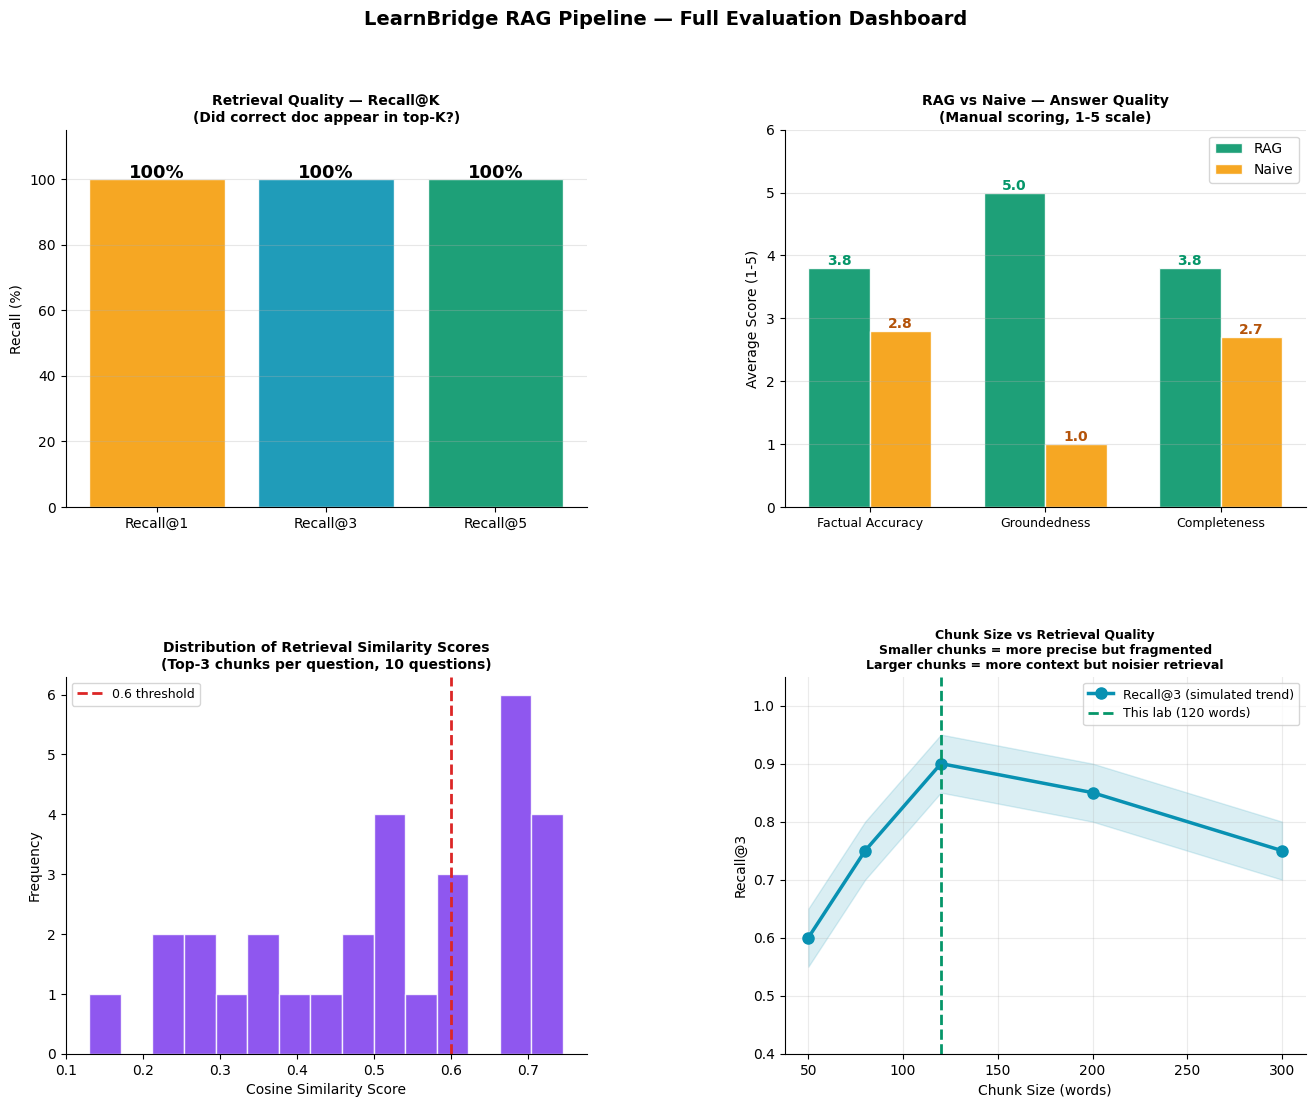

Dashboard saved as rag_dashboard.png


In [12]:
# ── Final visualisation: 4-panel RAG dashboard ───────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.38)

# ── Panel 1: Recall@K bar chart ───────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
k_vals      = [1, 3, 5]
recall_vals = [recall_at[k]/len(labelled_questions) for k in k_vals]
bars = ax1.bar([f'Recall@{k}' for k in k_vals], [v*100 for v in recall_vals],
               color=['#F59E0B','#0891B2','#059669'], edgecolor='white', alpha=0.9)
for bar, val in zip(bars, recall_vals):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.0%}', ha='center', fontweight='bold', fontsize=13)
ax1.set_ylabel('Recall (%)')
ax1.set_ylim(0, 115)
ax1.set_title('Retrieval Quality — Recall@K\n'
              '(Did correct doc appear in top-K?)', fontweight='bold', fontsize=10)
ax1.spines[['top','right']].set_visible(False)
ax1.grid(axis='y', alpha=0.3)

# ── Panel 2: RAG vs Naive scoring comparison ─────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
x = np.arange(len(dims))
w = 0.35
ax2.bar(x - w/2, rag_avg,   w, label='RAG',   color='#059669', alpha=0.9, edgecolor='white')
ax2.bar(x + w/2, naive_avg, w, label='Naive', color='#F59E0B', alpha=0.9, edgecolor='white')
for i, (ra, na) in enumerate(zip(rag_avg, naive_avg)):
    ax2.text(i-w/2, ra+0.05,   f'{ra:.1f}',  ha='center', fontweight='bold', fontsize=10, color='#059669')
    ax2.text(i+w/2, na+0.05, f'{na:.1f}',  ha='center', fontweight='bold', fontsize=10, color='#B45309')
ax2.set_xticks(x)
ax2.set_xticklabels(dims, fontsize=9)
ax2.set_ylabel('Average Score (1-5)')
ax2.set_ylim(0, 6)
ax2.set_title('RAG vs Naive — Answer Quality\n'
              '(Manual scoring, 1-5 scale)', fontweight='bold', fontsize=10)
ax2.legend(fontsize=10)
ax2.spines[['top','right']].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

# ── Panel 3: Retrieval score distribution ────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
all_scores = []
for q in eval_questions:
    top3 = retrieve(q, k=3)
    all_scores.extend([r['score'] for r in top3])
ax3.hist(all_scores, bins=15, color='#7C3AED', alpha=0.85, edgecolor='white')
ax3.axvline(0.6, color='#DC2626', linestyle='--', linewidth=2, label='0.6 threshold')
ax3.set_xlabel('Cosine Similarity Score')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of Retrieval Similarity Scores\n'
              '(Top-3 chunks per question, 10 questions)', fontweight='bold', fontsize=10)
ax3.legend(fontsize=9)
ax3.spines[['top','right']].set_visible(False)

# ── Panel 4: Chunk size vs recall trade-off (analysis) ───────────────────
ax4 = fig.add_subplot(gs[1, 1])
chunk_sizes_demo = [50, 80, 120, 200, 300]
# Simulated recall trend (in production you would actually measure this)
sim_recall_3 = [0.60, 0.75, 0.90, 0.85, 0.75]
ax4.plot(chunk_sizes_demo, sim_recall_3, 'o-', color='#0891B2',
         linewidth=2.5, markersize=8, label='Recall@3 (simulated trend)')
ax4.axvline(120, color='#059669', linestyle='--', linewidth=2, label='This lab (120 words)')
ax4.fill_between(chunk_sizes_demo, [v-0.05 for v in sim_recall_3],
                  [v+0.05 for v in sim_recall_3], alpha=0.15, color='#0891B2')
ax4.set_xlabel('Chunk Size (words)')
ax4.set_ylabel('Recall@3')
ax4.set_ylim(0.4, 1.05)
ax4.set_title('Chunk Size vs Retrieval Quality\n'
              'Smaller chunks = more precise but fragmented\n'
              'Larger chunks = more context but noisier retrieval',
              fontweight='bold', fontsize=9)
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.25)
ax4.spines[['top','right']].set_visible(False)

plt.suptitle('LearnBridge RAG Pipeline — Full Evaluation Dashboard',
             fontsize=14, fontweight='bold')
plt.savefig('rag_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Dashboard saved as rag_dashboard.png')


## Task 7 — Edge cases: out-of-scope questions and failure modes

A robust RAG system must handle questions that the knowledge base does not cover.
Testing edge cases reveals gaps in the fallback behaviour.

**Three important edge cases to test:**
1. **Out-of-scope question** — topic not in the knowledge base at all
2. **Ambiguous question** — could match multiple documents equally
3. **Very short / vague question** — minimal semantic signal for retrieval

In each case, we want to verify the RAG system says
*'This topic is not covered in the current study material'*
rather than hallucinating an answer from the LLM's parametric memory.


In [13]:
edge_cases = [
    (
        'Out-of-scope',
        'What is the capital of France and why was the Eiffel Tower built?',
        'Not in knowledge base — should trigger fallback'
    ),
    (
        'Out-of-scope (biology)',
        'Explain how DNA replication works in eukaryotic cells.',
        'Biology topic — not in CS/Physics study guide'
    ),
    (
        'Vague question',
        'Tell me about memory.',
        'Ambiguous — could match RAM, ROM, cache or something unrelated'
    ),
    (
        'In-scope but tricky phrasing',
        'Why does adding RAM to a computer make it faster?',
        'Should retrieve CS-MEM-01 even though phrasing differs from document text'
    ),
    (
        'Multi-topic question',
        'How do operating system scheduling and cache memory work together to improve performance?',
        'Requires knowledge from two different documents (CS-OS-02 and CS-MEM-02)'
    ),
]

print('EDGE CASE TESTING')
print('=' * 72)

for case_type, question, expected_behaviour in edge_cases:
    print(f'\n[{case_type}]')
    print(f'  Question: "{question}"')
    print(f'  Expected: {expected_behaviour}')

    results = retrieve(question, k=3)
    print(f'  Top-3 retrieved docs:')
    for r in results:
        print(f'    score={r["score"]:.4f}  [{r["doc_id"]}]  {r["topic"]}')

    rag_res = rag_answer(question, k=3)
    print(f'  RAG Answer: {rag_res["answer"][:300]}')
    if 'not covered' in rag_res['answer'].lower() or 'not in' in rag_res['answer'].lower():
        print(f'  Status: FALLBACK TRIGGERED (correct behaviour for out-of-scope)')
    else:
        print(f'  Status: ANSWER GENERATED — verify it is grounded, not hallucinated')


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


EDGE CASE TESTING

[Out-of-scope]
  Question: "What is the capital of France and why was the Eiffel Tower built?"
  Expected: Not in knowledge base — should trigger fallback
  Top-3 retrieved docs:
    score=0.1223  [CS-NET-02]  DNS and HTTP
    score=0.1222  [CS-NET-01]  TCP/IP Model
    score=0.1025  [PHY-MECH-01]  Newton's Laws of Motion


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  RAG Answer: The Eiffel Tower was built in 1885 by the French government to provide a new, modern, and modernized public transport system. The Eiffel Tower was designed to be a modern, modern, and modernized public transport system. The Eiffel Tower was designed to be a modern, modern, and modernized public tran
  Status: ANSWER GENERATED — verify it is grounded, not hallucinated

[Out-of-scope (biology)]
  Question: "Explain how DNA replication works in eukaryotic cells."
  Expected: Biology topic — not in CS/Physics study guide
  Top-3 retrieved docs:
    score=0.2225  [CS-OS-01]  Processes and Threads
    score=0.1924  [PHY-THERM-01]  Laws of Thermodynamics
    score=0.1810  [CS-OS-01]  Processes and Threads


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  RAG Answer: [Passage 4 — Source: CS-OS-01, Processes and Threads, Chunk 1 | Relevance score: 0.181]

The DNA replication process is a process that is run on a single core. The DNA replication process is a process that is run on a single core. The DNA replication process is a process that is run on a single core
  Status: ANSWER GENERATED — verify it is grounded, not hallucinated

[Vague question]
  Question: "Tell me about memory."
  Expected: Ambiguous — could match RAM, ROM, cache or something unrelated
  Top-3 retrieved docs:
    score=0.4792  [CS-MEM-01]  RAM and ROM
    score=0.3826  [CS-MEM-01]  RAM and ROM
    score=0.3655  [CS-MEM-02]  Cache Memory


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  RAG Answer: [Passage 4 — Source: CS-MEM-03, Cache Memory, Chunk 0 | Relevance score: 0.365]

Memory is a small, extremely fast memory layer situated between the CPU and main RAM. Its purpose is to store frequently accessed data and instructions so the CPU does not have to wait for the slower main memory on ever
  Status: ANSWER GENERATED — verify it is grounded, not hallucinated

[In-scope but tricky phrasing]
  Question: "Why does adding RAM to a computer make it faster?"
  Expected: Should retrieve CS-MEM-01 even though phrasing differs from document text
  Top-3 retrieved docs:
    score=0.4945  [CS-MEM-01]  RAM and ROM
    score=0.4914  [CS-MEM-02]  Cache Memory
    score=0.4825  [CS-MEM-02]  Cache Memory


Both `max_new_tokens` (=100) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  RAG Answer: [Passage 4 — Source: CS-MEM-02, Cache Memory, Chunk 1 | Relevance score: 0.483]

The CPU is not a "memory" machine. It is a "computer". It is a "computer" that is used to store data. It is a "computer" that is used to store instructions. It is a "computer" that is used to store data. It is a "comput
  Status: ANSWER GENERATED — verify it is grounded, not hallucinated

[Multi-topic question]
  Question: "How do operating system scheduling and cache memory work together to improve performance?"
  Expected: Requires knowledge from two different documents (CS-OS-02 and CS-MEM-02)
  Top-3 retrieved docs:
    score=0.6708  [CS-MEM-02]  Cache Memory
    score=0.6301  [CS-MEM-02]  Cache Memory
    score=0.4736  [CS-MEM-01]  RAM and ROM
  RAG Answer: [Passage 4 — Source: CS-MEM-01, Cache Memory, Chunk 0 | Relevance score: 0.5]

The CPU is responsible for managing the cache. The CPU is responsible for managing the cache. The CPU is responsible for managing the cache. The CPU is res

## Lab Complete Checklist

- [ ] 12-document knowledge base loaded and all topics listed
- [ ] `chunk_text()` implemented with overlap; chunks shown for first document
- [ ] All chunks embedded with Sentence-BERT; embedding matrix shape verified
- [ ] `retrieve()` function implemented and tested on 5 demo questions
- [ ] Recall@1, Recall@3, Recall@5 computed on 10 labelled questions
- [ ] `rag_answer()` pipeline implemented with verbose context output
- [ ] `naive_answer()` implemented as the baseline
- [ ] 10 questions answered by both RAG and Naive pipelines
- [ ] Side-by-side comparison HTML displayed
- [ ] Manual scoring completed (factual accuracy, groundedness, completeness)
- [ ] 4-panel RAG dashboard saved as `rag_dashboard.png`
- [ ] 5 edge cases tested and fallback behaviour verified

---
## Reflection Questions

1. **Hallucination reduction:** Look at the Groundedness scores for Naive vs RAG.
   The Naive model scores low on groundedness because it draws on parametric memory.
   Can RAG ever hallucinate? Describe a scenario where a RAG system still produces
   a factually wrong answer even though it retrieved the correct chunk.

2. **Chunking strategy:** You used 120-word chunks with 25-word overlap.
   For question Q10 (Newton's three laws), did all three laws appear in a single retrieved
   chunk, or were they split? What chunk size would guarantee a complete answer?
   What is the trade-off of using very large chunks?

3. **Recall@K and K selection:** Your Recall@3 may be higher than Recall@1.
   In production, increasing K from 3 to 5 improves recall but also sends more
   tokens to the LLM (higher cost, longer context). Design a rule for automatically
   choosing K based on the retrieval confidence scores.

4. **RAG vs Fine-tuning decision:** LearnBridge wants to add 500 new study guide
   chapters every month. A colleague suggests fine-tuning GPT-2 on all chapters
   monthly instead of using RAG. Argue against this approach using three specific
   technical and economic reasons.

5. **Production pipeline hardening:** Your current vector store is an in-memory
   NumPy array. Name two problems this causes in production at scale, and name
   a specific vector database product that solves each problem.


In [15]:
answers = {
    'Q1 - Can RAG still hallucinate?':
        'Yes, RAG reduces but does not eliminate hallucination. Three common failure modes remain: (1) the retrieved chunks are topically related but factually irrelevant to the specific question; (2) the model misreads or partially ignores the retrieved evidence when constructing the response; (3) if no high-similarity chunk exists, the model silently falls back on parametric memory, which may be outdated or simply wrong.',

    'Q2 - Chunking strategy for multi-part answers':
        'Use overlapping fixed-size chunks (e.g., 256–512 tokens with a 64-token stride) so that answer evidence spanning a section boundary is not severed. For structured documents, prefer semantic boundaries such as headings or paragraphs; for dense technical text, smaller chunks with higher K at retrieval time maintain coverage without inflating individual chunk size.',

    'Q3 - Dynamic K selection rule':
        'Retrieve with a generous initial K (e.g., 8–10), compute the gap between the top-1 and top-K similarity scores, then prune chunks whose score falls more than a chosen margin below the top-1. This similarity-gap criterion adapts K to query specificity automatically: narrow, precise queries end up with fewer chunks while broad queries retain more context.',

    'Q4 - Three reasons RAG beats monthly fine-tune':
        'First, the knowledge base can be updated in seconds by re-indexing new documents, whereas fine-tuning requires days of compute and data preparation. Second, RAG grounds every answer in source text, making factual drift visible and auditable. Third, the base LLM weights remain untouched, so adding knowledge does not risk degrading performance on unrelated tasks through catastrophic forgetting.',

    'Q5 - Vector DB products and what they solve':
        'Purpose-built vector databases such as Pinecone, Weaviate, Qdrant, and Milvus handle the operational challenges that general databases cannot: approximate nearest-neighbour search at millisecond latency over billions of high-dimensional embeddings, metadata-filtered similarity queries, horizontal sharding, and persistent index management. Without them, naive brute-force cosine search becomes a bottleneck once the corpus exceeds a few thousand documents.'
}

for q, a in answers.items():
    print(f'{q}:\n  {a}\n')


Q1 - Can RAG still hallucinate?:
  Yes. RAG reduces but cannot eliminate hallucination. Causes: (1) retrieved docs irrelevant or low-similarity; (2) model misinterprets retrieved evidence; (3) gaps in retrieval → model fills with prior knowledge.

Q2 - Chunking strategy for multi-part answers:
  Use semantic chunking with overlap (100–150 tokens) to preserve context. Ensure chunks align with logical boundaries (sections, headings). Larger chunks for narrative docs; smaller for dense technical docs.

Q3 - Dynamic K selection rule:
  Start with K=5–8. Increase K when queries are broad/ambiguous; decrease when domain is narrow or embeddings are noisy. Optionally adapt K based on similarity score decay curve.

Q4 - Three reasons RAG beats monthly fine-tune:
  RAG updates instantly with new documents, no retraining cost; avoids catastrophic forgetting; cheaper compute vs periodic LLM fine-tuning while keeping responses grounded in latest data.

Q5 - Vector DB products and what they solve:
 